In [1]:
# IMPORT LIBRARY
import os
import time
import random
import numpy as np
import tensorflow as tf
from PIL import Image

from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint

In [2]:
# PARAMETER GLOBAL & SEED
DATASET_PATH = r"D:\Project Jupyter\MODELLING\Dataset_baruPR"

train_dir = os.path.join(DATASET_PATH, "train")
val_dir   = os.path.join(DATASET_PATH, "val")
test_dir  = os.path.join(DATASET_PATH, "test")

CLASSES = ["edible", "poisonous"]

IMG_SIZE = 224
BATCH_SIZE = 32

In [3]:
# DATA GENERATOR (RESCALE ONLY)
def preprocess_with_pad(image):
    image = tf.image.resize_with_pad(image, IMG_SIZE, IMG_SIZE)
    image = preprocess_input(image)
    return image


train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_with_pad,
    rotation_range=10,
    zoom_range=0.1,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_with_pad
)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_data = val_test_gen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_data = val_test_gen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


Found 2256 images belonging to 2 classes.
Found 282 images belonging to 2 classes.
Found 232 images belonging to 2 classes.


In [4]:
# MODEL MOBILENETV3 LARGE
base_model = MobileNetV3Large(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

# Freeze feature extractor
base_model.trainable = False

In [5]:
# Build model 
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(2, activation="softmax")
])

# COMPILE MODEL
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 MobilenetV3large (Functiona  (None, 7, 7, 960)        2996352   
 l)                                                              
                                                                 
 global_average_pooling2d (G  (None, 960)              0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               123008    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 2)                 258       
                                                                 
Total params: 3,119,618
Trainable params: 123,266
Non-tr

In [6]:
# Callback untuk early stopping dan menyimpan model terbaik
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [7]:
# TRAINING + TIME MEASUREMENT
start_time = time.time()

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[early_stop],
    verbose=1
)

end_time = time.time()

total_training_time = end_time - start_time
epochs_ran = len(history.history["loss"])

print(f"\nTotal Training Time : {total_training_time:.2f} seconds")
print(f"Average / Epoch    : {total_training_time / epochs_ran:.2f} seconds")
print(f"Training stopped at epoch : {epochs_ran}")

Epoch 1/25
71/71 [==============================] - 152s 2s/step - loss: 0.7676 - accuracy: 0.6272 - val_loss: 0.5083 - val_accuracy: 0.7518
Epoch 2/25
71/71 [==============================] - 140s 2s/step - loss: 0.5660 - accuracy: 0.7114 - val_loss: 0.4434 - val_accuracy: 0.7766
Epoch 3/25
71/71 [==============================] - 136s 2s/step - loss: 0.5114 - accuracy: 0.7522 - val_loss: 0.4154 - val_accuracy: 0.8121
Epoch 4/25
71/71 [==============================] - 154s 2s/step - loss: 0.4552 - accuracy: 0.7824 - val_loss: 0.3961 - val_accuracy: 0.8298
Epoch 5/25
71/71 [==============================] - 143s 2s/step - loss: 0.4247 - accuracy: 0.8036 - val_loss: 0.3644 - val_accuracy: 0.8404
Epoch 6/25
71/71 [==============================] - 157s 2s/step - loss: 0.3942 - accuracy: 0.8231 - val_loss: 0.3516 - val_accuracy: 0.8333
Epoch 7/25
71/71 [==============================] - 149s 2s/step - loss: 0.3708 - accuracy: 0.8391 - val_loss: 0.3402 - val_accuracy: 0.8369
Epoch 8/25
71

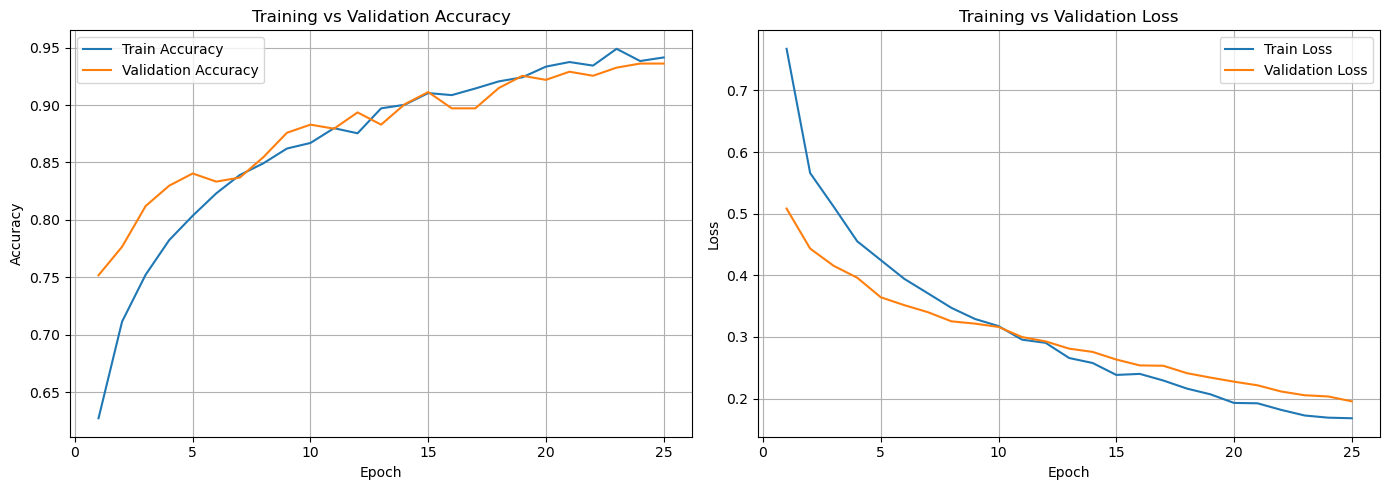

In [8]:
import matplotlib.pyplot as plt

# VISUALIZATION: ACCURACY & LOSS
epochs_range = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(14, 5))

# ----- Accuracy Plot -----
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history["accuracy"])
plt.plot(epochs_range, history.history["val_accuracy"])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.grid(True)

# ----- Loss Plot -----
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history["loss"])
plt.plot(epochs_range, history.history["val_loss"])
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train Loss", "Validation Loss"])
plt.grid(True)

plt.tight_layout()
plt.show()

In [9]:
# Waktu Inferensi Keseluruhan Test Set
start_time = time.time()

predictions = model.predict(test_data)

end_time = time.time()

inference_time_total = end_time - start_time
num_samples = test_data.samples

print(f"Total Inference Time (Test Set): {inference_time_total:.4f} seconds")
print(f"Average Inference Time per Image: {inference_time_total / num_samples:.6f} seconds")

8/8 [==============================] - 12s 1s/step
Total Inference Time (Test Set): 13.4355 seconds
Average Inference Time per Image: 0.057912 seconds


In [19]:
# Evaluasi Model (Test Set – Tetap Sama)
test_loss, test_acc = model.evaluate(test_data)
print(f"Test Accuracy: {test_acc:.4f}")

8/8 [==============================] - 11s 1s/step - loss: 0.1772 - accuracy: 0.9483
Test Accuracy: 0.9483


In [20]:
# Ambil 1 batch
x_batch, _ = next(test_data)

# Warm-up (penting untuk CNN)
_ = model.predict(x_batch[:1])

start_time = time.time()
_ = model.predict(x_batch[:1])
end_time = time.time()

print(f"Inference Time (Single Image): {(end_time - start_time):.6f} seconds")

1/1 [==============================] - 0s 61ms/step
Inference Time (Single Image): 0.115019 seconds


8/8 [==============================] - 11s 1s/step

Classification Report:
              precision    recall  f1-score   support

      edible       0.94      0.97      0.95       120
   poisonous       0.96      0.93      0.95       112

    accuracy                           0.95       232
   macro avg       0.95      0.95      0.95       232
weighted avg       0.95      0.95      0.95       232


Confusion Matrix:


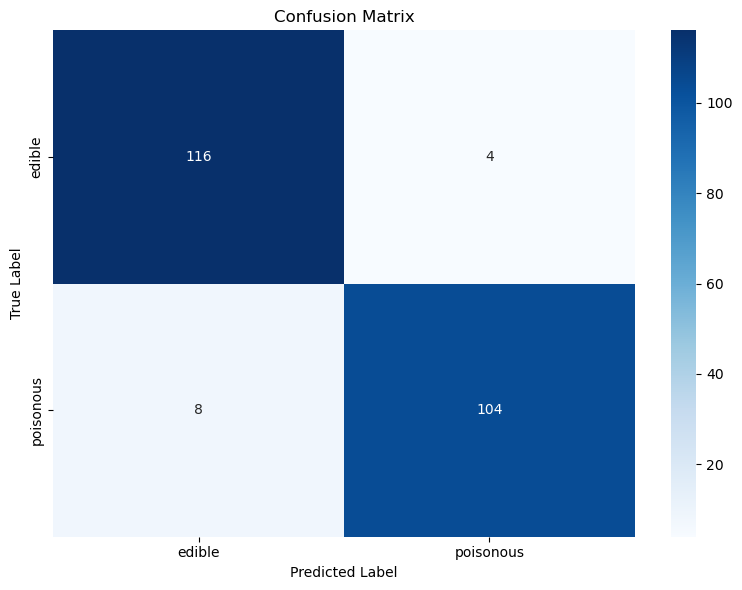

In [21]:
# CONFUSION MATRIX & REPORT
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

y_true = test_data.classes
y_pred = np.argmax(model.predict(test_data), axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)

# Visualisasi
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,          # tampilkan angka
    fmt="d",             # integer
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [25]:

BASE_MODEL_KERAS_PATH = r"D:\Project Jupyter\FINAL\mobilenetv3Large_25COPYBARUFIXTF2_PREPRO.keras"

# Simpan model
model.save(BASE_MODEL_KERAS_PATH, save_format="keras")

print(f"✅ Model berhasil disimpan dalam format .keras: {BASE_MODEL_KERAS_PATH}")



✅ Model berhasil disimpan dalam format .keras: D:\Project Jupyter\FINAL\mobilenetv3Large_25COPYBARUFIXTF2_PREPRO.keras


In [27]:
BASE_MODEL_TF_PATH = r"D:\Project Jupyter\MODEL\mobilenetv3Large_jamur25COPYBARUFIXTF2PREPRO_tf"

# Simpan model
model.save(BASE_MODEL_TF_PATH, save_format="tf")

print(f"✅ Model berhasil disimpan dalam format SavedModel TensorFlow: {BASE_MODEL_TF_PATH}")


INFO:tensorflow:Assets written to: D:\Project Jupyter\MODEL\mobilenetv3Large_jamur25COPYBARUFIXTF2PREPRO_tf\assets


INFO:tensorflow:Assets written to: D:\Project Jupyter\MODEL\mobilenetv3Large_jamur25COPYBARUFIXTF2PREPRO_tf\assets


✅ Model berhasil disimpan dalam format SavedModel TensorFlow: D:\Project Jupyter\MODEL\mobilenetv3Large_jamur25COPYBARUFIXTF2PREPRO_tf


In [28]:
import os

# Ukuran file .keras
size_keras = os.path.getsize(BASE_MODEL_KERAS_PATH) / (1024 * 1024)  # MB

# Ukuran folder SavedModel
def get_folder_size_mb(folder_path):
    total = 0
    for root, dirs, files in os.walk(folder_path):
        for f in files:
            total += os.path.getsize(os.path.join(root, f))
    return total / (1024 * 1024)  # MB

size_tf = get_folder_size_mb(BASE_MODEL_TF_PATH )

print(f"Ukuran Base model (.keras)      : {size_keras:.2f} MB")
print(f"Ukuran Base model (SavedModel)  : {size_tf:.2f} MB")


Ukuran Base model (.keras)      : 13.20 MB
Ukuran Base model (SavedModel)  : 17.87 MB
